In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 
import matplotlib.pyplot as plt 
import matplotlib as mpl

# 1D cases analysis

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')
plog_paths = glob.glob('../plogs/*/*/*/*.json')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

  0%|          | 0/17376 [00:00<?, ?it/s]

100%|██████████| 17376/17376 [03:11<00:00, 90.83it/s]  


In [ ]:
plog1d_df = load_profile_log()

## filt useless result from test_l2

### trend on different residual type without coarsen

In [8]:
log1d_filt_df, not_enough1d = log_filt_1d(log1d_df)

### All type model with all type residuals and no coarsen on 4096

- model : fno1d, ft1d, gt1d, lno1d
- dataset : burgers, cosine, lnabs
- residuals : null, diag, ml1, ml2, ml3, ml4 
- resolution : 4096

In [40]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 8192) & (log1d_filt_df.coarse_level == 0)]
table_4096_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_4096_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
burgers fno1d  0.0055  0.0039  0.0043  0.0046  0.0049  0.0053
        gt1d   0.0375  0.0328  0.0352  0.0344  0.0225  0.0212
        lno1d  0.0462  0.0205  0.0262  0.0287  0.0361  0.0321
cosine  fno1d  0.0210  0.0223  0.0213  0.0208  0.0203  0.0193
        gt1d   0.0189  0.0200  0.0206  0.0217  0.0140  0.0155
        lno1d  0.0198  0.0057  0.0073  0.0067  0.0054  0.0065
lnabs   fno1d  0.0182  0.0124  0.0118  0.0109  0.0106  0.0101
        gt1d   0.0349  0.0303  0.0309  0.0276  0.0263  0.0208
        lno1d  0.0579  0.0247  0.0259  0.0267  0.0298  0.0270

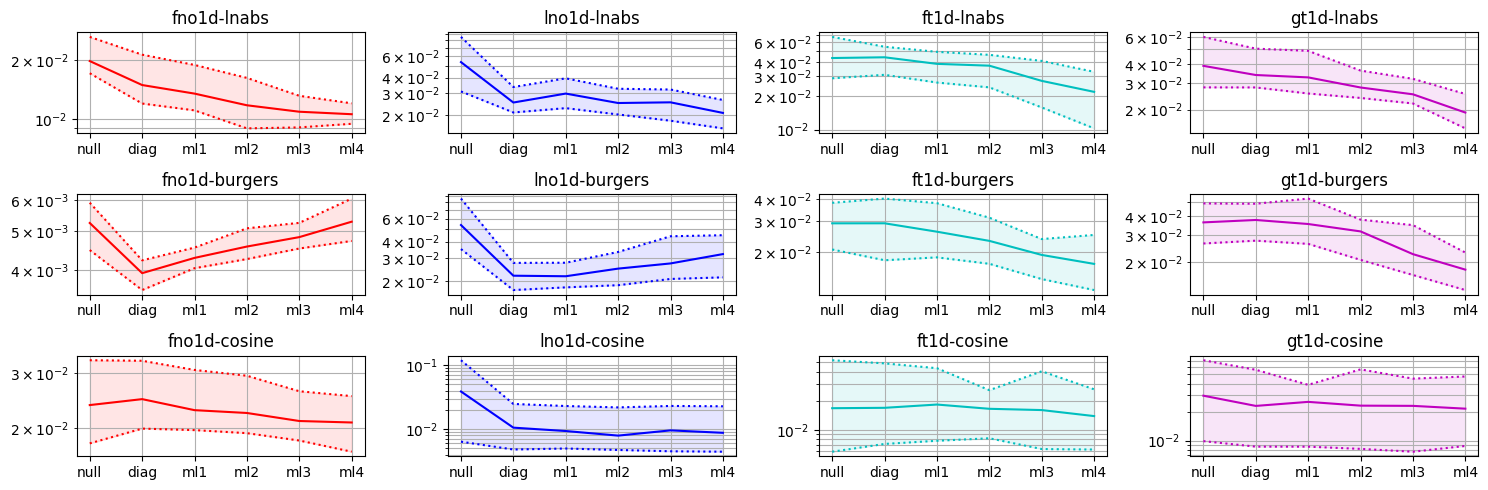

In [38]:
fig = vis_all_model_dataset_residual_trend_on_fix_resolution(log1d_filt_df, resolution=4096)

- for smooth kernel integral(cosine), we didn't observe the significance of using residuals correction.
- for singular smooth kernel intergal(lnabs), we observe the significance of using residuals, and more level correction we use the better result we will get
- for learning solution operator of burgres' equation, we observe the significance of using residuals on ft/gt

since the method we use to approximate gloabl kernel integral operation if different, the performance of residual correction operation will behave a little bit different.

### All type model with all coarsen and diag-ml4 on 4096

In [42]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 4096) & (log1d_filt_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

In [43]:
table_mean.round(4)

coarse_level        0       1       2       3       4
dataset model                                        
burgers fno1d  0.0039  0.0039  0.0039  0.0039  0.0040
        ft1d   0.0265  0.0328  0.0316  0.0282  0.0271
        gt1d   0.0359  0.0372  0.0396  0.0365  0.0400
        lno1d  0.0223  0.0220  0.0217  0.0206  0.0226
cosine  fno1d  0.0224  0.0220  0.0243  0.0245  0.0307
        ft1d   0.0145  0.0128  0.0118  0.0160  0.0294
        gt1d   0.0213  0.0155  0.0240  0.0191  0.0362
        lno1d  0.0060  0.0056  0.0080  0.0114  0.0219
lnabs   fno1d  0.0125  0.0126  0.0132  0.0153  0.0208
        ft1d   0.0438  0.0396  0.0475  0.0451  0.0444
        gt1d   0.0304  0.0341  0.0325  0.0322  0.0395
        lno1d  0.0238  0.0245  0.0247  0.0247  0.0286

### trend on same resolution with different coarsen level

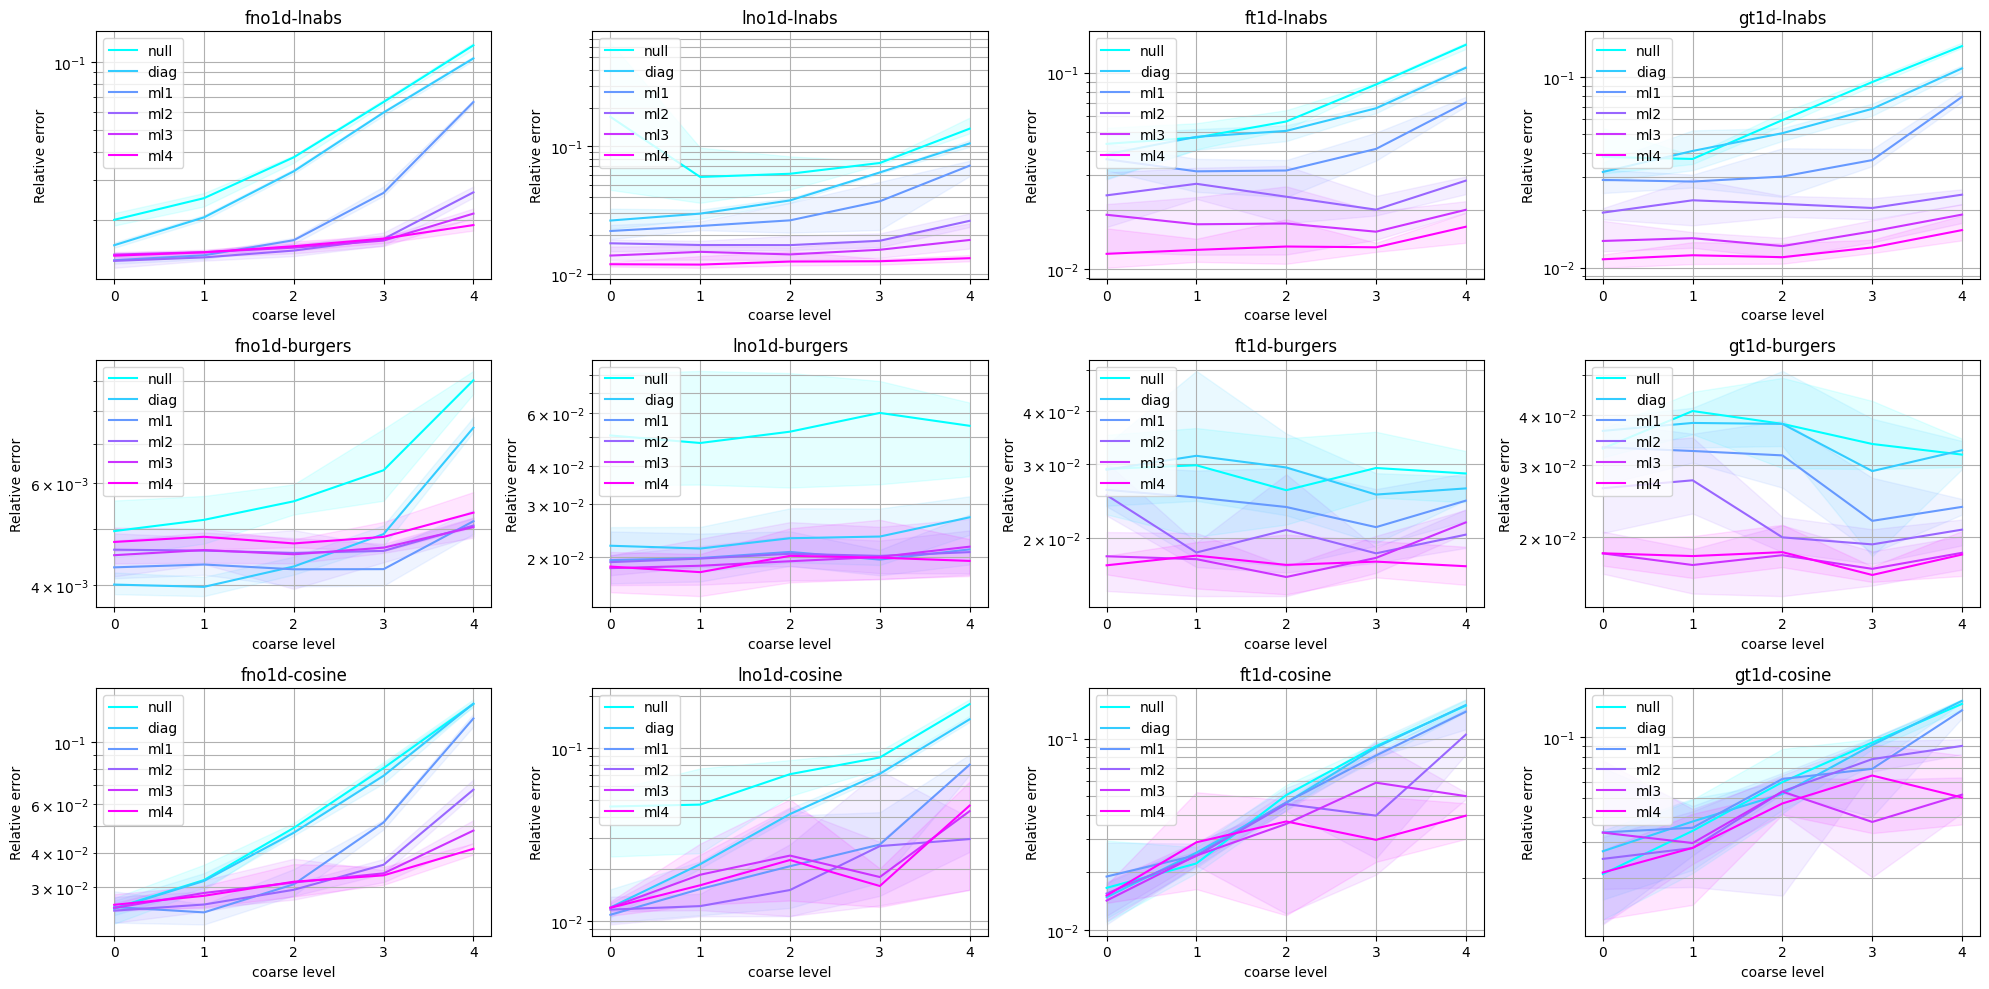

In [24]:
vis_all_model_dataset_residual_trend_on_fix_resolution_and_coarse_level(log1d_filt_df, resolution=512)

### trend on different residual type on different coarsen level

In [47]:
table_mean = log1d_filt_df.pivot_table(values='test_l2', index=['model', 'resolution', 'residual'], columns=['dataset', 'coarse_level'], aggfunc=np.mean)

In [48]:
table_mean

dataset                     burgers                                           
coarse_level                      0         1         2         3         4   
model resolution residual                                                     
fno1d 512        diag      0.004011  0.003975  0.004310  0.004902  0.007478  \
                 ml1       0.004295  0.004344  0.004262  0.004265  0.005159   
                 ml2       0.004608  0.004590  0.004549  0.004586  0.005071   
                 ml3       0.004508  0.004601  0.004524  0.004645  0.005040   
                 ml4       0.004751  0.004850  0.004723  0.004848  0.005338   
...                             ...       ...       ...       ...       ...   
lno1d 8192       ml1       0.026247  0.022079  0.023100  0.026480  0.025912   
                 ml2       0.028667  0.033165  0.027232  0.030171  0.029420   
                 ml3       0.036064  0.034249  0.026434  0.033567  0.033827   
                 ml4       0.032097  0.037501  0.031929  0.027617  0.028782   
                 null      0.046237  0.051892  0.044506  0.046209  0.050072   

dataset                      cosine                                           
coarse_level                      0         1         2         3         4   
model resolution residual                                                     
fno1d 512        diag      0.025120  0.031619  0.047191  0.075752  0.137848  \
                 ml1       0.025472  0.024356  0.030760  0.051422  0.121918   
                 ml2       0.024709  0.026001  0.029382  0.036175  0.067485   
                 ml3       0.025272  0.028616  0.031215  0.033685  0.048051   
                 ml4       0.025935  0.027953  0.031424  0.033128  0.041292   
...                             ...       ...       ...       ...       ...   
lno1d 8192       ml1       0.007259  0.006236  0.005857  0.007467  0.010942   
                 ml2       0.006692  0.005058  0.005630  0.007399  0.010777   
                 ml3       0.005353  0.007001  0.006438  0.007598  0.010531   
                 ml4       0.006473  0.006920  0.006552  0.007102  0.008672   
                 null      0.019783  0.031051  0.028979  0.032793  0.043038   

dataset                       lnabs                                          
coarse_level                      0         1         2         3         4  
model resolution residual                                                    
fno1d 512        diag      0.015502  0.020583  0.032902  0.059799  0.103734  
                 ml1       0.013310  0.013990  0.016317  0.026405  0.066544  
                 ml2       0.013217  0.013694  0.014682  0.016524  0.026550  
                 ml3       0.014091  0.014441  0.015124  0.016255  0.021387  
                 ml4       0.013938  0.014427  0.015344  0.016581  0.019031  
...                             ...       ...       ...       ...       ...  
lno1d 8192       ml1       0.025876  0.027906  0.028601  0.027336  0.029244  
                 ml2       0.026731  0.027507  0.027104  0.027502  0.030122  
                 ml3       0.029791  0.026024  0.027986  0.026841  0.026206  
                 ml4       0.027013  0.024879  0.024179  0.026152  0.026197  
                 null      0.057873  0.048793  0.066127  0.045369  0.048398  

[120 rows x 15 columns]

In [14]:
# for model_nm in ['ft1d', 'gt1d', 'fno1d', 'lno1d']:
#     model1d_df = log1d_agg_df[(log1d_agg_df.model == model_nm)]
#     model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model1d_table = model1d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(40, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)
    
#     bmin = model1d_table['burgers'].min().min()
#     bmax = model1d_table['burgers'].max().max()
#     plt.subplot(1,4,1)
#     plt.title('burgers')
#     sns.heatmap(model1d_table['burgers'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=bmin, vmax=bmax)

#     pmin = model1d_table['poisson'].min().min()
#     pmax = model1d_table['poisson'].max().max()
#     plt.subplot(1,4,2)
#     plt.title('poisson')
#     sns.heatmap(model1d_table['poisson'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=pmin, vmax=pmax)

#     cmin = model1d_table['cosine'].min().min()
#     cmax = model1d_table['cosine'].max().max()
#     plt.subplot(1,4,3)
#     plt.title('cosine')
#     sns.heatmap(model1d_table['cosine'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=cmin, vmax=cmax)

#     lmin = model1d_table['lnabs'].min().min()
#     lmax = model1d_table['lnabs'].max().max()
#     plt.subplot(1,4,4)
#     plt.title('lnabs')
#     sns.heatmap(model1d_table['lnabs'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=lmin, vmax=lmax)

In [15]:
# 2D cases analysis

In [2]:
log2d_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log2d_df = load_accuracy_log(log2d_paths)

100%|██████████| 5873/5873 [01:10<00:00, 83.10it/s] 


In [3]:
filt = []
not_enough = []
for model in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
    for dataset in ['darcy', 'invdist']:
        for coarse_level in [0, 1, 2, 3]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3']:
                for resolution in [85, 141, 211, 421]:
                    sub_df = log2d_df[(log2d_df.model == model) & (log2d_df.dataset == dataset) & (log2d_df.coarse_level == coarse_level) & (log2d_df.residual == residual) & (log2d_df.resolution == resolution)]
                    filt_df = sub_df.sort_values(by='test_l2').iloc[:5]
                    if (filt_df.shape[0] < 5) & (coarse_level == 0):
                        if not pass_check(model, resolution, coarse_level, residual, ' '):
                            not_enough.append([model, dataset, coarse_level, residual, resolution, filt_df.seed.tolist()])
                    
                    filt.append(filt_df)

log2d_filt_df = pd.concat(filt)

  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem


In [4]:
pd.DataFrame(not_enough, columns=['model_nm', 'dataset', 'coarse_level', 'residual', 'resolution', 'seeds']).sort_values(['model_nm', 'residual'])

,model_nm,dataset,coarse_level,residual,resolution,seeds
0,fno2d,darcy,0,diag,421,"[0, 3]"
4,fno2d,invdist,0,diag,421,[0]
1,fno2d,darcy,0,ml1,421,"[3, 0]"
5,fno2d,invdist,0,ml1,421,[0]
2,fno2d,darcy,0,ml2,421,"[0, 3]"
6,fno2d,invdist,0,ml2,421,[0]
3,fno2d,darcy,0,ml3,421,[0]
7,fno2d,invdist,0,ml3,421,[0]
9,gt2d,darcy,0,diag,421,[]
16,gt2d,invdist,0,diag,421,[]


In [5]:
len(not_enough)

23

### trend on different residual type without coarsen

In [6]:
sub_df = log2d_filt_df[(log2d_filt_df.resolution == 141) & (log2d_filt_df.coarse_level == 0)]
table_141_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_141_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3  ml4
dataset model                                             
darcy   fno2d  0.0338  0.0127  0.0110  0.0105  0.0114  NaN
        gt2d   0.0541  0.0398  0.0204  0.0140  0.0098  NaN
        lno2d  0.0603  0.0275  0.0216  0.0171  0.0127  NaN
invdist fno2d  0.0322  0.0027  0.0027  0.0028  0.0030  NaN
        gt2d   0.0124  0.0116  0.0055  0.0039  0.0031  NaN
        lno2d  0.0432  0.0097  0.0052  0.0044  0.0034  NaN

In [7]:
sub_df = log2d_filt_df[(log2d_df.resolution == 141) & (log2d_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

/tmp/ipykernel_272935/1915998661.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub_df = log2d_filt_df[(log2d_df.resolution == 141) & (log2d_df.residual == 'diag')]


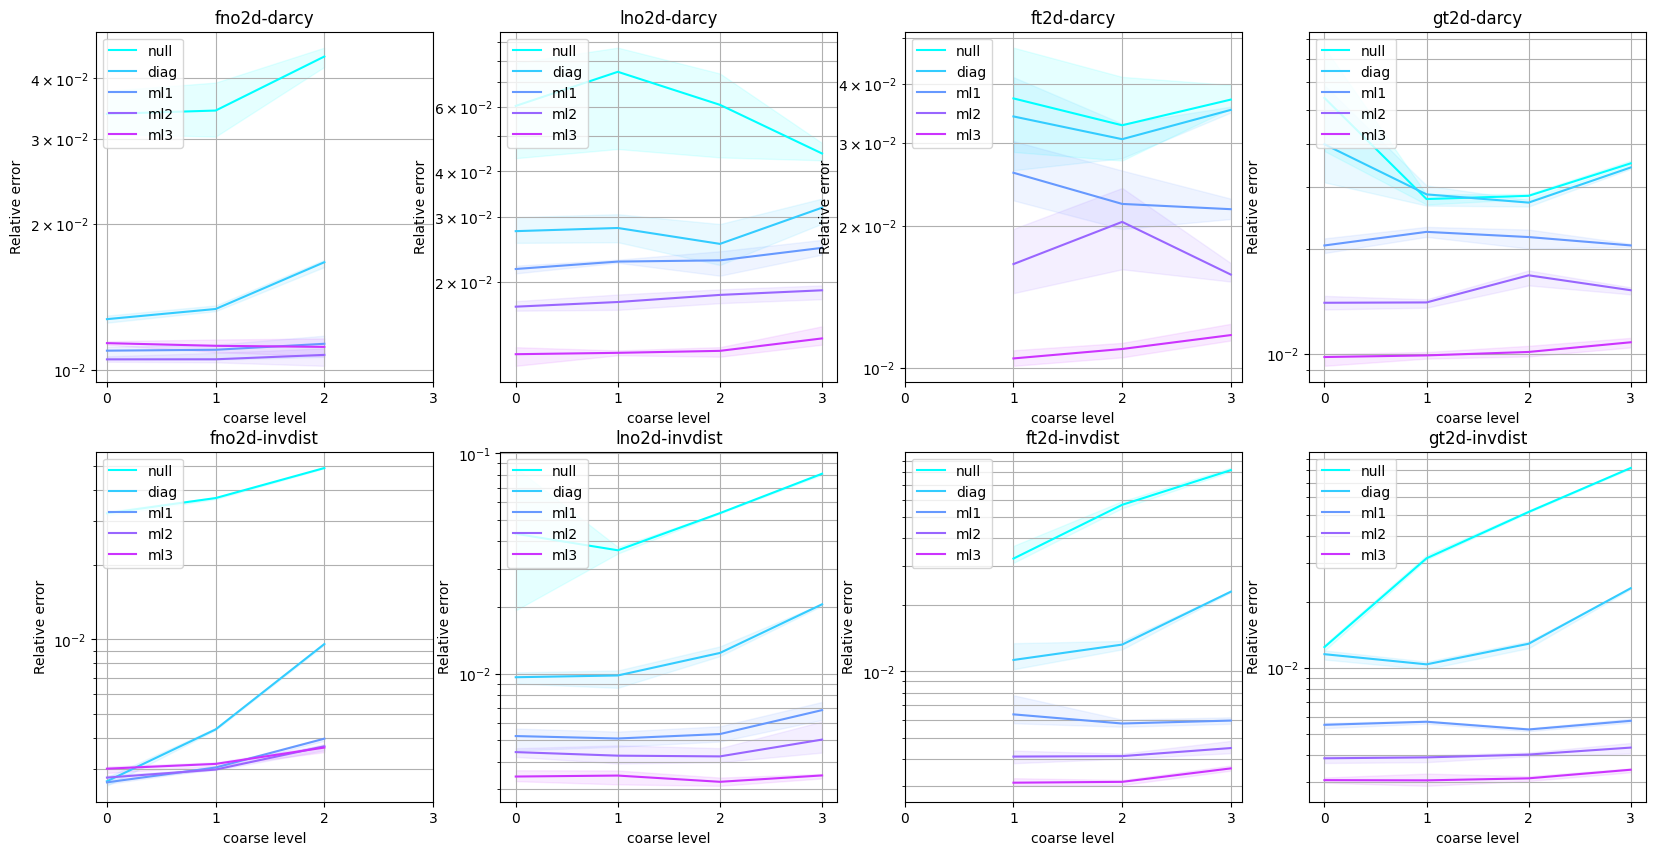

In [35]:
resolution = 141
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
sub_df = log2d_filt_df[log2d_filt_df.resolution == resolution]
colors = mpl.colormaps['cool']
coarse_levels = [0, 1, 2, 3]
for m, model in enumerate(['fno2d', 'lno2d', 'ft2d', 'gt2d']):
    for d, dataset in enumerate(['darcy', 'invdist']):
        subsub_df = sub_df[(sub_df.model == model) & (sub_df.dataset == dataset)]            
        
        if len(subsub_df) != 0 :
            table_mean = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.mean)
            table_min = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.min)
            table_max = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.max)
            
            for r, residual in enumerate(['null', 'diag', 'ml1', 'ml2', 'ml3']):
                axs[d][m].plot(table_mean.index, table_mean[[residual]].values.reshape(-1), "-",color=colors(r*0.2), label=residual)
                axs[d][m].fill_between(table_mean.index, 
                                    table_min[[residual]].values.reshape(-1),
                                    table_max[[residual]].values.reshape(-1), color=colors(r*0.2), alpha=0.1)
                
            axs[d][m].set_xticks(coarse_levels)
            axs[d][m].set_xticklabels(coarse_levels)
            axs[d][m].set_title("{:}-{:}".format(model, dataset))
            axs[d][m].set_yscale('log')
            axs[d][m].grid(axis='both', which='both')
            axs[d][m].legend(loc='upper left')
            axs[d][m].set_xlabel('coarse level')
            axs[d][m].set_ylabel('Relative error')

### trend on same resolution with different coarsen level

KeyError: "None of [Index(['null'], dtype='object', name='residual')] are in the [columns]"

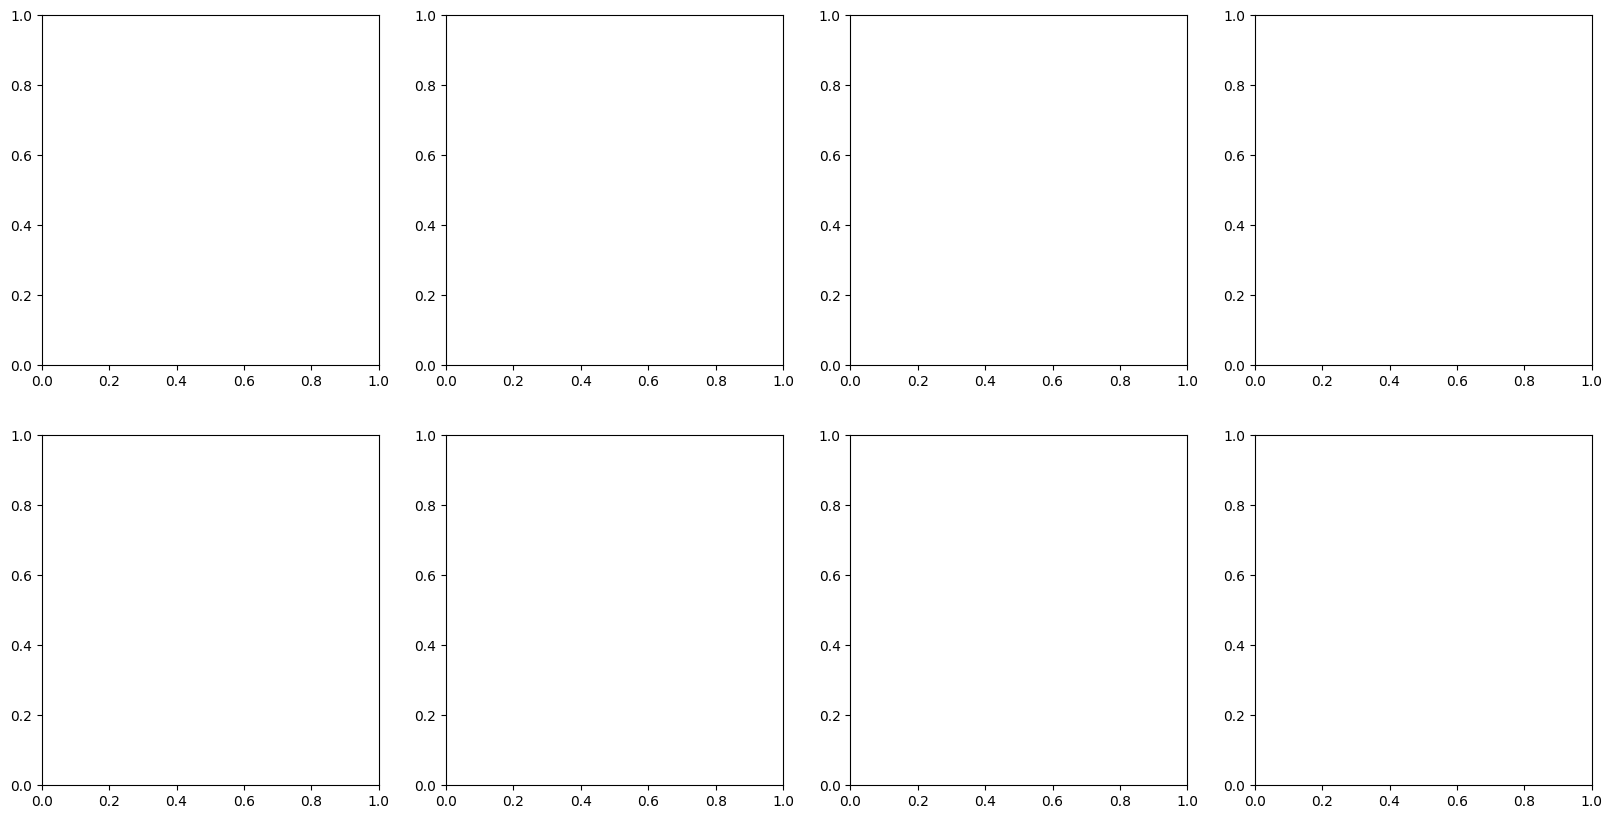

In [11]:
vis_all_model_dataset2d_residual_trend_on_fix_resolution_and_coarse_level(log2d_filt_df, resolution=141)

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     sub_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.resolution == 85)]
#     g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', row='dataset', kind='point', col_order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     model2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm)]
#     model2d_table = pd.pivot_table(model2d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model2d_table = model2d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model2d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(20, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)

#     plt.subplot(1,2,1)
#     plt.title('darcy')
#     sns.heatmap(model2d_table['darcy'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)
#     plt.subplot(1,2,2)
#     plt.title('invdist')
#     sns.heatmap(model2d_table['invdist'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)